# Analisis dan Validasi Data ISPU DKI Jakarta

Notebook ini digunakan untuk mendemonstrasikan hasil eksplorasi data, identifikasi masalah kualitas data, proses validasi, strategi penanganan, dan penentuan objek data analisis pada dataset **Indeks Standar Pencemar Udara (ISPU) DKI Jakarta**.

Fokus notebook:

1. EDA: statistik deskriptif, distribusi nilai per kolom, dan nilai unik variabel kategorik.
2. Identifikasi masalah kualitas data: jenis masalah, lokasi kolom/baris, jumlah data terdampak, cleaning log, strategi, dan justifikasi.
3. Validasi data: konsistensi antar kolom serta kesesuaian nilai dengan definisi variabel.
4. Objek data: target, prediktor, granularitas, dan pertimbangan pemilihan.

> Catatan prinsip: dataset asli dipertahankan sebagai `df_raw`. Semua perbaikan dilakukan pada salinan `df_work` dan hasil akhir dibentuk sebagai `df_analysis` agar data lineage tetap jelas.

## 1. Persiapan Library dan Lokasi Dataset

Blok ini menyiapkan library yang digunakan untuk membaca data, melakukan validasi, membuat ringkasan statistik, serta menampilkan grafik sederhana.

In [45]:
import csv
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

In [46]:

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

PROJECT_ROOT = Path(r"C:\Users\pusda\Documents\repos\data-analysis-ispu")
DATA_PATH = PROJECT_ROOT / "data" / "ispu_jakarta_clean.csv"

print(f"Dataset digunakan: {DATA_PATH.resolve()}")

Dataset digunakan: C:\Users\pusda\Documents\repos\data-analysis-ispu\data\ispu_jakarta_clean.csv


## 2. Load Dataset Mentah

Data dibaca tanpa perubahan awal. Variabel `df_raw` menjadi titik awal/data lineage untuk semua proses validasi berikutnya.

In [47]:
df_raw = pd.read_csv(DATA_PATH)

print("Ukuran dataset mentah:")
print(f"- Jumlah baris : {df_raw.shape[0]:,}")
print(f"- Jumlah kolom : {df_raw.shape[1]:,}")

print("\nContoh 5 baris pertama:")
display(df_raw.head())

print("\nNama kolom:")
display(pd.DataFrame({"no": range(1, len(df_raw.columns) + 1), "kolom": df_raw.columns}))

Ukuran dataset mentah:
- Jumlah baris : 14,577
- Jumlah kolom : 12

Contoh 5 baris pertama:


,tanggal,periode_data,pm10,pm25,so2,co,o3,no2,max,critical,categori,stasiun
0,2010-01-01,"201,001.000",60.000,NaN,4.000,73.000,27.000,14.000,73.000,CO,SEDANG,DKI1 Bunderan HI
1,2010-01-02,"201,001.000",32.000,NaN,2.000,16.000,33.000,9.000,33.000,O3,BAIK,DKI1 Bunderan HI
2,2010-01-03,"201,001.000",27.000,NaN,2.000,19.000,20.000,9.000,27.000,PM10,BAIK,DKI1 Bunderan HI
3,2010-01-04,"201,001.000",22.000,NaN,2.000,16.000,15.000,6.000,22.000,PM10,BAIK,DKI1 Bunderan HI
4,2010-01-05,"201,001.000",25.000,NaN,2.000,17.000,15.000,8.000,25.000,PM10,BAIK,DKI1 Bunderan HI



Nama kolom:


,no,kolom
0,1,tanggal
1,2,periode_data
2,3,pm10
3,4,pm25
4,5,so2
5,6,co
6,7,o3
7,8,no2
8,9,max
9,10,critical


**Interpretasi awal:** dataset berformat tabular dengan satu baris merepresentasikan observasi ISPU pada tanggal dan stasiun tertentu. Validasi berikutnya akan memastikan apakah asumsi satu baris = satu tanggal-stasiun selalu terpenuhi.

## 3. EDA: Struktur, Tipe Data, dan Missing Values

Bagian ini menampilkan tipe data hasil pembacaan awal serta jumlah/persentase nilai kosong per kolom. Hasil ini menjadi dasar untuk membedakan isu struktur, isu kelengkapan, dan isu validitas nilai.

In [48]:
structure_summary = pd.DataFrame({
    "kolom": df_raw.columns,
    "tipe_data_awal": [str(dtype) for dtype in df_raw.dtypes],
    "jumlah_non_null": df_raw.notna().sum().values,
    "jumlah_null": df_raw.isna().sum().values,
    "persen_null": (df_raw.isna().mean().values * 100).round(2),
    "jumlah_nilai_unik_termasuk_null": df_raw.nunique(dropna=False).values,
})

display(structure_summary)

,kolom,tipe_data_awal,jumlah_non_null,jumlah_null,persen_null,jumlah_nilai_unik_termasuk_null
0,tanggal,str,14577,0,0.000,4774
1,periode_data,float64,14576,1,0.010,167
2,pm10,float64,14576,1,0.010,596
3,pm25,float64,5517,9060,62.150,1722
4,so2,float64,14573,4,0.030,377
5,co,float64,14576,1,0.010,231
6,o3,float64,14576,1,0.010,483
7,no2,float64,14576,1,0.010,237
8,max,float64,14576,1,0.010,266
9,critical,str,14576,1,0.010,11


**Interpretasi:** kolom numerik terbaca sebagai `float64` karena terdapat nilai kosong. Kolom `tanggal`, `critical`, `categori`, dan `stasiun` terbaca sebagai objek/string. Missing value terbesar perlu dicek pada `pm25` karena dapat mengindikasikan perubahan ketersediaan parameter pemantauan dari waktu ke waktu, bukan sekadar error input.

In [49]:
POLLUTANT_COLUMNS = ["pm10", "pm25", "so2", "co", "o3", "no2"]
NUMERIC_COLUMNS = ["periode_data", *POLLUTANT_COLUMNS, "max"]
CATEGORICAL_COLUMNS = ["critical", "categori", "stasiun"]

## 4. EDA: Statistik Deskriptif Variabel Numerik

Statistik deskriptif digunakan untuk melihat rentang nilai, pusat distribusi, variasi, serta indikasi nilai ekstrem awal pada parameter pencemar dan nilai ISPU maksimum.

In [50]:
numeric_descriptive = df_raw[NUMERIC_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_descriptive)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
periode_data,"14,576.000","201,728.239",387.308,"201,001.000","201,005.000","201,107.000","201,407.000","201,705.000","202,103.000","202,307.000","202,311.000","202,311.000"
pm10,"14,576.000",54.471,18.792,2.000,11.000,22.000,43.000,55.500,65.000,83.000,106.000,179.000
pm25,"5,517.000",74.700,22.719,13.000,30.000,46.000,57.032,72.000,88.112,116.000,136.000,287.000
so2,"14,573.000",23.611,14.765,0.000,1.000,4.000,12.000,21.000,32.000,52.000,57.000,112.000
co,"14,576.000",20.847,13.325,0.000,4.000,6.000,11.000,18.000,27.000,45.000,65.250,135.000
o3,"14,576.000",60.756,39.158,3.000,9.000,16.000,32.000,54.000,79.000,133.375,208.250,314.000
no2,"14,576.000",14.294,9.731,0.000,2.000,3.000,8.000,13.000,18.000,30.000,45.000,135.000
max,"14,576.000",76.921,34.533,1.000,20.000,33.000,55.000,72.000,91.000,136.250,208.000,840.000


**Interpretasi:** nilai minimum dan maksimum awal perlu dibandingkan dengan definisi ISPU dan konsistensi antar parameter. Secara umum, parameter ISPU tidak semestinya bernilai negatif. Nilai `max` yang sangat tinggi perlu ditelusuri apakah benar berasal dari salah satu parameter pencemar atau merupakan anomali data.

## 5. EDA: Distribusi Nilai Numerik per Kolom

Histogram berikut membantu membaca bentuk distribusi masing-masing parameter pencemar. Distribusi yang sangat miring, memiliki lonjakan tidak wajar, atau mengandung nilai ekstrem akan menjadi kandidat pemeriksaan kualitas data.

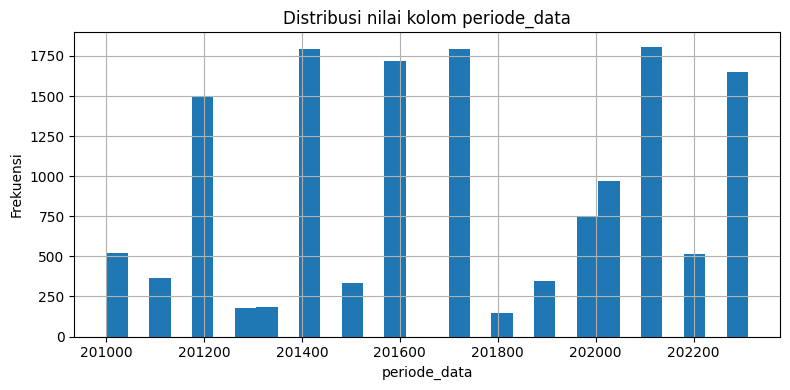

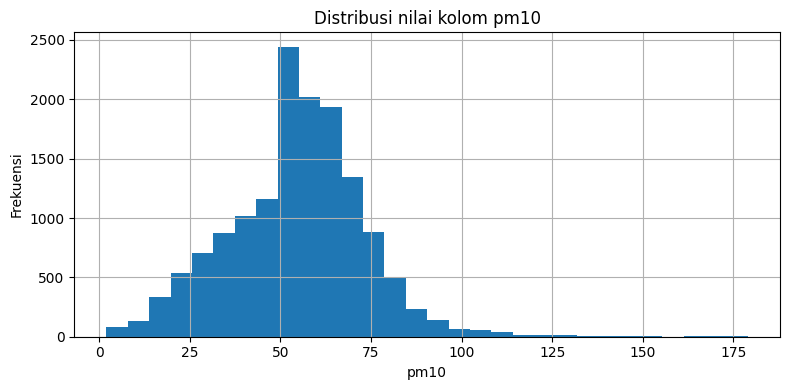

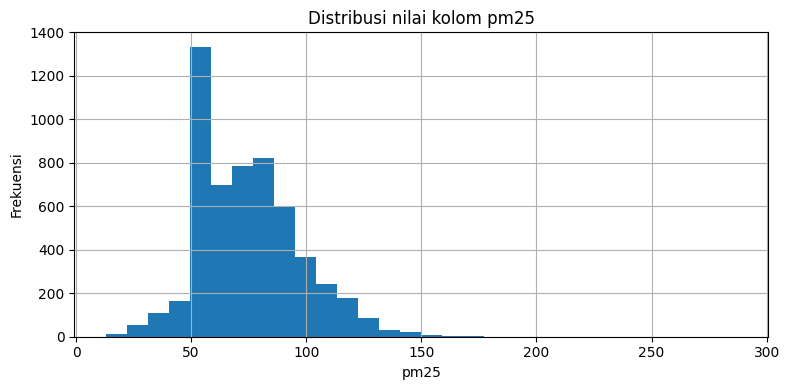

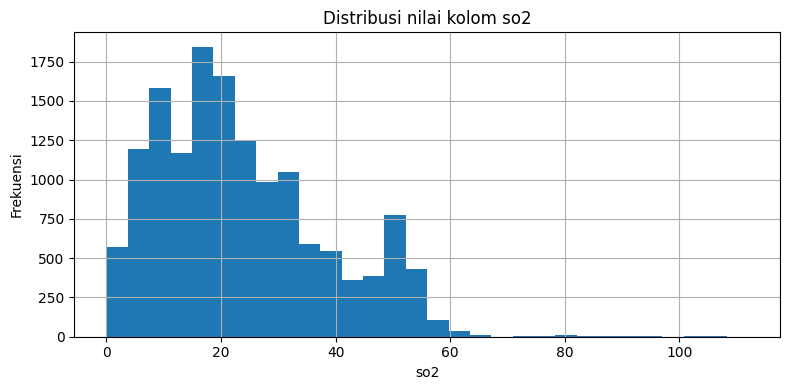

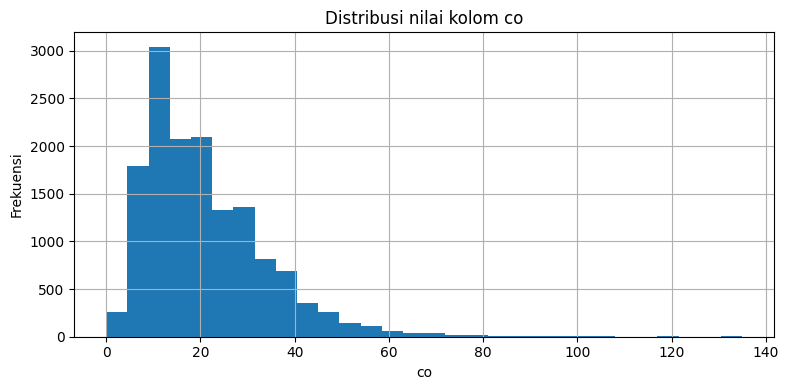

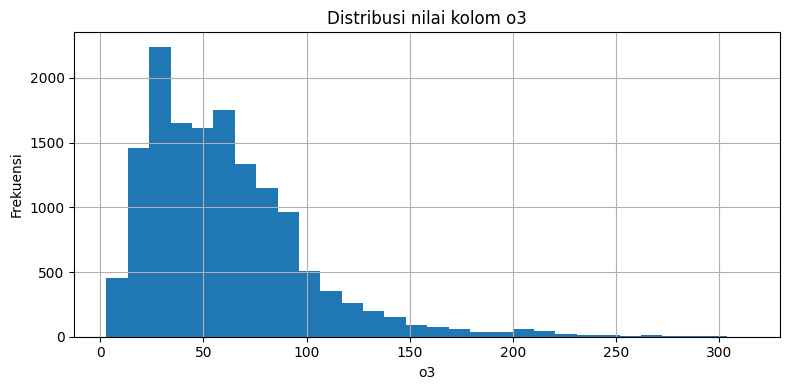

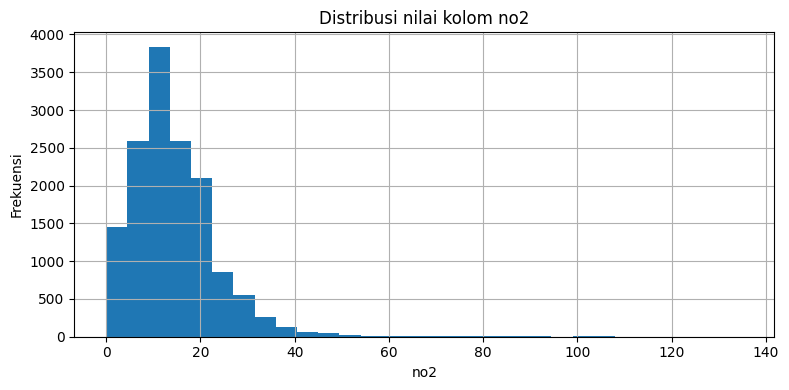

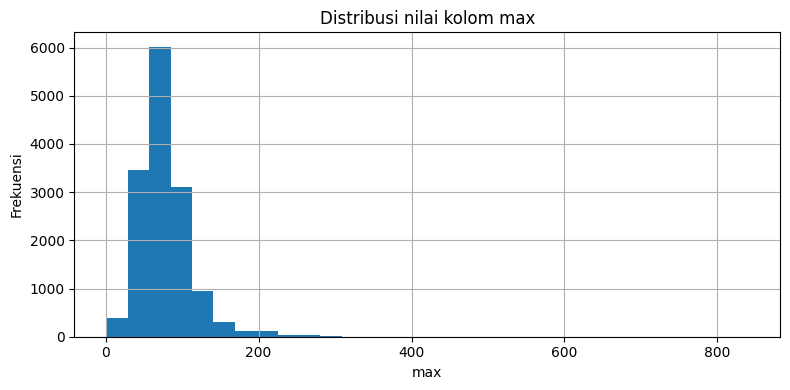

In [51]:
for col in NUMERIC_COLUMNS:
    plt.figure(figsize=(8, 4))
    df_raw[col].dropna().hist(bins=30)
    plt.title(f"Distribusi nilai kolom {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

## 6. EDA: Nilai Unik dan Distribusi Variabel Kategorik

Bagian ini menampilkan daftar nilai unik, frekuensi, dan persentase untuk `critical`, `categori`, dan `stasiun`. Nilai kategorik yang tidak termasuk domain seharusnya akan ditandai sebagai masalah kualitas data.

Kolom kategorik: critical
Nilai unik:


,nilai_unik
0,1
1,2
2,3
3,5
4,CO
5,NO2
6,O3
7,PM10
8,PM2.5
9,SO2


,critical,jumlah,persen
0,O3,6643,45.570
1,PM10,3609,24.760
2,PM2.5,3483,23.890
3,CO,397,2.720
4,SO2,287,1.970
5,2,112,0.770
6,1,30,0.210
7,3,7,0.050
8,NO2,5,0.030
9,5,3,0.020


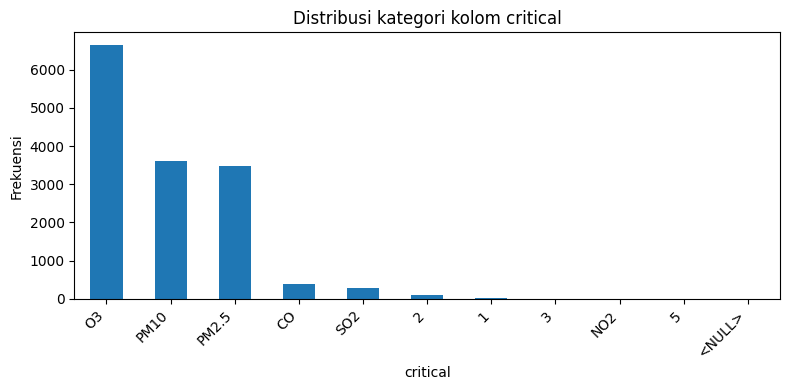

Kolom kategorik: categori
Nilai unik:


,nilai_unik
0,BAIK
1,BERBAHAYA
2,LUARBIASA
3,SANGAT TIDAK SEHAT
4,SEDANG
5,TIDAK SEHAT


,categori,jumlah,persen
0,SEDANG,9731,66.760
1,BAIK,2398,16.450
2,TIDAK SEHAT,2258,15.490
3,SANGAT TIDAK SEHAT,187,1.280
4,BERBAHAYA,1,0.010
5,NaN,1,0.010
6,LUARBIASA,1,0.010


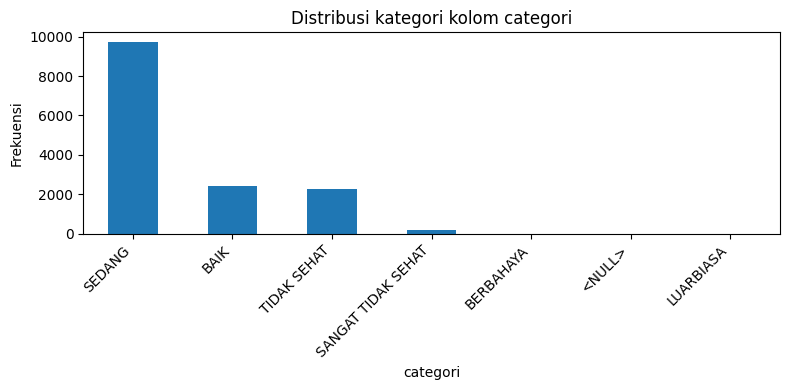

Kolom kategorik: stasiun
Nilai unik:


,nilai_unik
0,DKI1 Bunderan HI
1,DKI2 Kelapa Gading
2,DKI3 Jagakarsa
3,DKI4 Lubang Buaya
4,DKI5 Kebon Jeruk


,stasiun,jumlah,persen
0,DKI4 Lubang Buaya,3345,22.950
1,DKI1 Bunderan HI,2940,20.170
2,DKI3 Jagakarsa,2929,20.090
3,DKI2 Kelapa Gading,2881,19.760
4,DKI5 Kebon Jeruk,2481,17.020
5,NaN,1,0.010


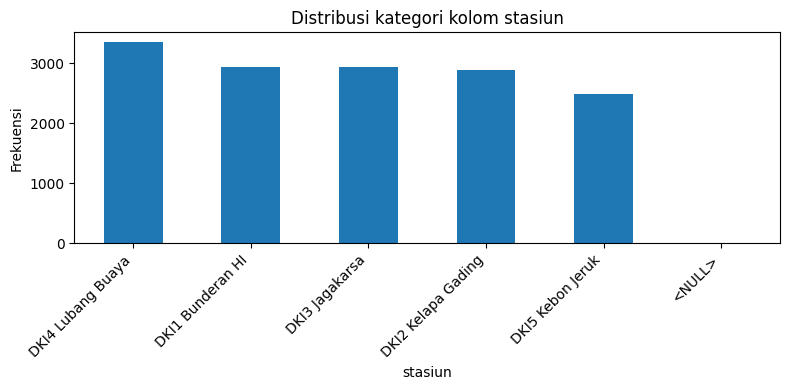

In [52]:
for col in CATEGORICAL_COLUMNS:
    print("=" * 90)
    print(f"Kolom kategorik: {col}")
    unique_values = pd.Series(df_raw[col].dropna().unique(), name="nilai_unik").sort_values(ignore_index=True)
    print("Nilai unik:")
    display(unique_values.to_frame())
    
    freq = (
        df_raw[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="jumlah")
    )
    freq["persen"] = (freq["jumlah"] / len(df_raw) * 100).round(2)
    display(freq)
    
    plt.figure(figsize=(8, 4))
    plot_data = df_raw[col].fillna("<NULL>").value_counts().head(20)
    plot_data.plot(kind="bar")
    plt.title(f"Distribusi kategori kolom {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Interpretasi:** kolom `critical` perlu distandarkan karena ditemukan nilai numerik yang tampaknya merepresentasikan kode parameter pencemar. Kolom `categori` perlu divalidasi karena kategori ISPU seharusnya hanya terdiri dari BAIK, SEDANG, TIDAK SEHAT, SANGAT TIDAK SEHAT, dan BERBAHAYA.

## 7. EDA: Periode Waktu dan Cakupan Stasiun

Bagian ini memeriksa periode tanggal yang tersedia dan cakupan stasiun pemantauan. Pemeriksaan dilakukan sebelum cleaning penuh agar potensi masalah tanggal terlihat dari data mentah.

In [53]:
tanggal_parse_awal = pd.to_datetime(df_raw["tanggal"], errors="coerce")

coverage_summary = pd.DataFrame({
    "metrik": [
        "tanggal_min_parse_awal",
        "tanggal_max_parse_awal",
        "jumlah_tanggal_unik_parse_awal",
        "jumlah_tanggal_tidak_valid_parse_awal",
        "jumlah_stasiun_unik_non_null",
    ],
    "nilai": [
        tanggal_parse_awal.min(),
        tanggal_parse_awal.max(),
        tanggal_parse_awal.nunique(),
        tanggal_parse_awal.isna().sum(),
        df_raw["stasiun"].nunique(dropna=True),
    ]
})

display(coverage_summary)

station_coverage = (
    df_raw.assign(tanggal_parse=tanggal_parse_awal)
    .groupby("stasiun", dropna=False)
    .agg(
        jumlah_baris=("tanggal", "size"),
        tanggal_min=("tanggal_parse", "min"),
        tanggal_max=("tanggal_parse", "max"),
        jumlah_tanggal_unik=("tanggal_parse", "nunique"),
    )
    .reset_index()
    .sort_values("stasiun", na_position="last")
)

display(station_coverage)

,metrik,nilai
0,tanggal_min_parse_awal,2010-01-01 00:00:00
1,tanggal_max_parse_awal,2023-11-30 00:00:00
2,jumlah_tanggal_unik_parse_awal,4773
3,jumlah_tanggal_tidak_valid_parse_awal,1
4,jumlah_stasiun_unik_non_null,5


,stasiun,jumlah_baris,tanggal_min,tanggal_max,jumlah_tanggal_unik
0,DKI1 Bunderan HI,2940,2010-01-01,2023-11-30,2891
1,DKI2 Kelapa Gading,2881,2010-11-04,2023-11-30,2792
2,DKI3 Jagakarsa,2929,2010-11-07,2023-11-30,2837
3,DKI4 Lubang Buaya,3345,2010-11-04,2023-11-30,3143
4,DKI5 Kebon Jeruk,2481,2012-11-27,2023-11-30,2417
5,NaN,1,NaT,NaT,0


**Interpretasi:** hasil cakupan waktu dan stasiun akan divalidasi ulang setelah perbaikan baris malformed dan koreksi tanggal/periode, karena satu baris yang rusak dapat membuat tanggal tidak terbaca dan stasiun menjadi kosong.

# Bagian B — Identifikasi Masalah Kualitas Data dan Cleaning Log

Pada bagian ini, notebook membuat salinan kerja `df_work`, memperbaiki masalah yang dapat diperbaiki secara deterministik, dan mencatat semua tindakan dalam `cleaning_log`.

## 8. Membuat Salinan Kerja dan Memperbaiki Baris Malformed

Baris malformed adalah baris CSV yang seluruh isi record-nya tidak sengaja masuk ke satu kolom. Deteksi dilakukan dengan mencari baris ketika kolom selain `tanggal` kosong, tetapi nilai `tanggal` mengandung koma seperti satu record CSV lengkap.

In [54]:
df_work = df_raw.copy().astype(object)
df_work.insert(0, "row_id_original", df_work.index)
base_columns = list(df_raw.columns)
cleaning_log = []

malformed_mask = (
    df_work[base_columns].drop(columns=["tanggal"]).isna().all(axis=1)
    & df_work["tanggal"].astype(str).str.contains(",", regex=False, na=False)
)
malformed_indices = df_work.index[malformed_mask].tolist()

print(f"Jumlah baris malformed terdeteksi: {len(malformed_indices)}")
if malformed_indices:
    display(df_work.loc[malformed_indices, ["row_id_original", *base_columns]])

for idx in malformed_indices:
    parsed = next(csv.reader([str(df_work.at[idx, "tanggal"])], skipinitialspace=False))
    parsed = [np.nan if str(value).strip() == "" else str(value).strip() for value in parsed]
    if len(parsed) == len(base_columns):
        before_value = df_work.at[idx, "tanggal"]
        df_work.loc[idx, base_columns] = parsed
        cleaning_log.append({
            "issue_id": "Q01",
            "jenis_masalah": "Baris malformed/record CSV masuk ke satu kolom",
            "kolom_terdampak": ", ".join(base_columns),
            "baris_terdampak_contoh": str([int(idx)]),
            "jumlah_data_terdampak": 1,
            "strategi_penanganan": "Parse ulang string CSV dan isi kembali ke kolom yang sesuai",
            "justifikasi": "Pola memiliki jumlah elemen sama dengan jumlah kolom sehingga perbaikan bersifat deterministik",
        })
    else:
        cleaning_log.append({
            "issue_id": "Q01",
            "jenis_masalah": "Baris malformed gagal diparse",
            "kolom_terdampak": ", ".join(base_columns),
            "baris_terdampak_contoh": str([int(idx)]),
            "jumlah_data_terdampak": 1,
            "strategi_penanganan": "Flag untuk investigasi manual",
            "justifikasi": "Jumlah elemen hasil parsing tidak sama dengan jumlah kolom",
        })

if malformed_indices:
    print("Setelah perbaikan baris malformed:")
    display(df_work.loc[malformed_indices, ["row_id_original", *base_columns]])

Jumlah baris malformed terdeteksi: 1


,row_id_original,tanggal,periode_data,pm10,pm25,so2,co,o3,no2,max,critical,categori,stasiun
8234,8234,"2021-08-25,202108,"" "",81.0,44.0,10.0,33.0,11.0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Setelah perbaikan baris malformed:


,row_id_original,tanggal,periode_data,pm10,pm25,so2,co,o3,no2,max,critical,categori,stasiun
8234,8234,2021-08-25,202108,NaN,81.0,44.0,10.0,33.0,11.0,81.0,PM2.5,SEDANG,DKI3 Jagakarsa


**Interpretasi:** perbaikan ini tidak mengubah makna data, hanya mengembalikan record ke struktur kolom yang benar. Jejak perbaikan disimpan pada `cleaning_log`.

## 9. Standarisasi Tipe Data dan Format Teks

Setelah struktur baris diperbaiki, kolom numerik dikonversi ke tipe numerik dan kolom teks distandarkan dengan trimming spasi. Kolom `tanggal_dt` dibuat sebagai representasi tanggal hasil parsing.

In [55]:
for col in NUMERIC_COLUMNS:
    df_work[col] = pd.to_numeric(df_work[col], errors="coerce")

for col in ["tanggal", *CATEGORICAL_COLUMNS]:
    df_work[col] = df_work[col].astype("string").str.strip()
    df_work[col] = df_work[col].replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})

df_work["tanggal_dt"] = pd.to_datetime(df_work["tanggal"], errors="coerce")

post_type_summary = pd.DataFrame({
    "kolom": ["row_id_original", *base_columns, "tanggal_dt"],
    "tipe_data_setelah_standardisasi": [str(df_work[col].dtype) for col in ["row_id_original", *base_columns, "tanggal_dt"]],
    "jumlah_null": [df_work[col].isna().sum() for col in ["row_id_original", *base_columns, "tanggal_dt"]],
})

display(post_type_summary)

,kolom,tipe_data_setelah_standardisasi,jumlah_null
0,row_id_original,int64,0
1,tanggal,string,0
2,periode_data,float64,0
3,pm10,float64,1
4,pm25,float64,9059
5,so2,float64,3
6,co,float64,0
7,o3,float64,0
8,no2,float64,0
9,max,float64,0


## 10. Validasi Missing Values Setelah Perbaikan Struktur

Tabel ini menunjukkan missing values setelah baris malformed diperbaiki. Perbedaan dari missing awal menunjukkan bahwa sebagian missing disebabkan oleh struktur baris yang rusak, bukan benar-benar hilang di sumber data.

In [56]:
missing_after_structure_fix = pd.DataFrame({
    "kolom": base_columns,
    "jumlah_missing": [df_work[col].isna().sum() for col in base_columns],
})
missing_after_structure_fix["persen_missing"] = (missing_after_structure_fix["jumlah_missing"] / len(df_work) * 100).round(2)
missing_after_structure_fix = missing_after_structure_fix.sort_values("jumlah_missing", ascending=False)

display(missing_after_structure_fix)

# Catat missing besar PM2.5 dan missing kecil pada parameter lain.
for col in ["pm25", "pm10", "so2"]:
    affected = df_work.index[df_work[col].isna()].tolist()
    if affected:
        cleaning_log.append({
            "issue_id": "Q02" if col == "pm25" else "Q03",
            "jenis_masalah": "Missing value pada parameter pencemar" if col != "pm25" else "Missing value besar pada PM2.5",
            "kolom_terdampak": col,
            "baris_terdampak_contoh": str([int(i) for i in affected[:10]]),
            "jumlah_data_terdampak": len(affected),
            "strategi_penanganan": "Tidak diimputasi; buat flag ketersediaan parameter dan hitung indikator validasi dari parameter yang tersedia",
            "justifikasi": "Imputasi dapat mengubah kategori pencemaran; missing PM2.5 tampak historis/sistematis sehingga perlu dipisahkan dari error input biasa",
        })

# Flag ketersediaan parameter.
for col in POLLUTANT_COLUMNS:
    df_work[f"{col}_is_missing"] = df_work[col].isna()

,kolom,jumlah_missing,persen_missing
3,pm25,9059,62.150
4,so2,3,0.020
2,pm10,1,0.010
1,periode_data,0,0.000
0,tanggal,0,0.000
5,co,0,0.000
6,o3,0,0.000
7,no2,0,0.000
8,max,0,0.000
9,critical,0,0.000


**Interpretasi:** missing `pm25` sangat besar dan sistematis sehingga tidak aman langsung diisi rata-rata/median. Untuk analisis kebijakan kualitas udara, imputasi nilai pencemar dapat menurunkan integritas kategori ISPU. Karena itu, strategi yang dipilih adalah mempertahankan missing, menambahkan flag, dan menghitung ulang indikator dari parameter yang tersedia.

## 11. Validasi Format Tanggal dan Konsistensi `periode_data`

`periode_data` seharusnya konsisten dengan bulan dan tahun pada `tanggal`. Contoh: `tanggal = 2023-11-30` seharusnya memiliki `periode_data = 202311`.

Notebook juga mendeteksi pola tanggal yang kemungkinan tertukar bulan-hari, misalnya `2020-01-11` dengan `periode_data = 202011`, yang dapat dikoreksi menjadi `2020-11-01` apabila hasil swap sesuai dengan periode data.

In [57]:
period_from_tanggal_awal = pd.to_numeric(df_work["tanggal_dt"].dt.strftime("%Y%m"), errors="coerce")
period_mismatch_mask = (
    df_work["tanggal_dt"].notna()
    & df_work["periode_data"].notna()
    & (df_work["periode_data"] != period_from_tanggal_awal)
)


def safe_swap_month_day(ts):
    if pd.isna(ts):
        return pd.NaT
    try:
        return pd.Timestamp(year=ts.year, month=ts.day, day=ts.month)
    except Exception:
        return pd.NaT

swapped_date = df_work["tanggal_dt"].apply(safe_swap_month_day)
swap_repair_mask = (
    period_mismatch_mask
    & swapped_date.notna()
    & (pd.to_numeric(swapped_date.dt.strftime("%Y%m"), errors="coerce") == df_work["periode_data"])
)

unresolved_period_mismatch_mask = period_mismatch_mask & ~swap_repair_mask

df_work["tanggal_validated"] = df_work["tanggal_dt"].where(~swap_repair_mask, swapped_date)
df_work["periode_data_validated"] = pd.to_numeric(df_work["tanggal_validated"].dt.strftime("%Y%m"), errors="coerce").astype("Int64")
df_work["flag_period_mismatch_unresolved"] = unresolved_period_mismatch_mask

date_validation_summary = pd.DataFrame({
    "pemeriksaan": [
        "tanggal gagal diparse",
        "periode_data tidak konsisten dengan tanggal awal",
        "periode_data mismatch yang dapat diperbaiki dengan swap bulan-hari",
        "periode_data mismatch yang masih unresolved",
    ],
    "jumlah_baris": [
        int(df_work["tanggal_dt"].isna().sum()),
        int(period_mismatch_mask.sum()),
        int(swap_repair_mask.sum()),
        int(unresolved_period_mismatch_mask.sum()),
    ]
})

display(date_validation_summary)

if period_mismatch_mask.any():
    sample_period_issues = df_work.loc[period_mismatch_mask, [
        "row_id_original", "tanggal", "tanggal_dt", "tanggal_validated", "periode_data", "periode_data_validated", "stasiun"
    ]].head(20)
    display(sample_period_issues)

if swap_repair_mask.any():
    cleaning_log.append({
        "issue_id": "Q04",
        "jenis_masalah": "Ketidakkonsistenan tanggal dan periode_data akibat indikasi bulan-hari tertukar",
        "kolom_terdampak": "tanggal, periode_data",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[swap_repair_mask].tolist()[:10]]),
        "jumlah_data_terdampak": int(swap_repair_mask.sum()),
        "strategi_penanganan": "Buat tanggal_validated dengan swap bulan-hari jika hasilnya cocok dengan periode_data",
        "justifikasi": "Perbaikan hanya dilakukan saat pola koreksi dapat dibuktikan cocok dengan periode_data",
    })

if unresolved_period_mismatch_mask.any():
    cleaning_log.append({
        "issue_id": "Q05",
        "jenis_masalah": "Ketidakkonsistenan tanggal dan periode_data yang tidak dapat dikoreksi otomatis",
        "kolom_terdampak": "tanggal, periode_data",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[unresolved_period_mismatch_mask].tolist()[:10]]),
        "jumlah_data_terdampak": int(unresolved_period_mismatch_mask.sum()),
        "strategi_penanganan": "Gunakan tanggal_validated dari tanggal yang berhasil diparse, regenerate periode_data_validated, dan flag untuk audit sumber data",
        "justifikasi": "Tidak ada bukti deterministik untuk mengubah tanggal; periode turunan dibuat konsisten untuk analisis waktu",
    })

,pemeriksaan,jumlah_baris
0,tanggal gagal diparse,0
1,periode_data tidak konsisten dengan tanggal awal,403
2,periode_data mismatch yang dapat diperbaiki de...,231
3,periode_data mismatch yang masih unresolved,172


,row_id_original,tanggal,tanggal_dt,tanggal_validated,periode_data,periode_data_validated,stasiun
1114,1114,2015-02-01,2015-02-01,2015-02-01,"201,202.000",201502,DKI1 Bunderan HI
1115,1115,2015-02-08,2015-02-08,2015-02-08,"201,202.000",201502,DKI1 Bunderan HI
1849,1849,2018-04-12,2018-04-12,2018-12-04,"201,812.000",201812,DKI1 Bunderan HI
1873,1873,2020-01-11,2020-01-11,2020-11-01,"202,011.000",202011,DKI1 Bunderan HI
1900,1900,2020-02-06,2020-02-06,2020-02-06,"202,202.000",202002,DKI1 Bunderan HI
1906,1906,2020-02-11,2020-02-11,2020-11-02,"202,011.000",202011,DKI1 Bunderan HI
1941,1941,2020-03-11,2020-03-11,2020-11-03,"202,011.000",202011,DKI1 Bunderan HI
1969,1969,2020-04-11,2020-04-11,2020-11-04,"202,011.000",202011,DKI1 Bunderan HI
2000,2000,2020-05-11,2020-05-11,2020-11-05,"202,011.000",202011,DKI1 Bunderan HI
2051,2051,2020-06-11,2020-06-11,2020-11-06,"202,011.000",202011,DKI1 Bunderan HI


**Interpretasi:** validasi waktu tidak hanya memeriksa format tanggal, tetapi juga hubungan antar kolom. Perbaikan otomatis dibatasi pada kasus yang punya pola jelas; sisanya diberi flag agar tidak menyembunyikan masalah kualitas sumber.

## 12. Standarisasi `critical` dan Validasi Parameter Dominan

Kolom `critical` seharusnya berisi nama parameter pencemar dominan. Karena ditemukan nilai numerik, notebook melakukan mapping kode numerik ke label parameter dan mengecek ulang apakah parameter tersebut konsisten dengan nilai maksimum parameter pencemar.

In [58]:
VALID_CATEGORIES = ["BAIK", "SEDANG", "TIDAK SEHAT", "SANGAT TIDAK SEHAT", "BERBAHAYA"]
VALID_CRITICAL = ["PM10", "PM2.5", "SO2", "CO", "O3", "NO2"]

POLLUTANT_LABEL_TO_COLUMN = {
    "PM10": "pm10",
    "PM2.5": "pm25",
    "SO2": "so2",
    "CO": "co",
    "O3": "o3",
    "NO2": "no2",
}

CRITICAL_NUMERIC_CODE_MAP = {
    "1": "PM10",
    "2": "PM2.5",
    "3": "SO2",
    "4": "CO",
    "5": "O3",
    "6": "NO2",
}

In [59]:
def recompute_max(row):
    """Menghitung ulang nilai maksimum dari kolom parameter pencemar yang tersedia."""
    return row[POLLUTANT_COLUMNS].max(skipna=True)


def recompute_critical(row):
    """Menentukan parameter pencemar dominan dari nilai maksimum parameter pencemar."""
    values = {label: row[col] for label, col in POLLUTANT_LABEL_TO_COLUMN.items() if pd.notna(row[col])}
    if not values:
        return pd.NA
    max_value = max(values.values())
    # Urutan tie-break mengikuti urutan kolom pencemar pada dataset.
    for label in VALID_CRITICAL:
        if label in values and np.isclose(values[label], max_value):
            return label
    return pd.NA

In [60]:
df_work["critical_original"] = df_work["critical"]
df_work["critical_standardized"] = (
    df_work["critical"]
    .astype("string")
    .str.upper()
    .str.strip()
    .replace(CRITICAL_NUMERIC_CODE_MAP)
)
df_work.loc[~df_work["critical_standardized"].isin(VALID_CRITICAL), "critical_standardized"] = pd.NA

df_work["max_recomputed"] = df_work.apply(recompute_max, axis=1)
df_work["critical_recomputed"] = df_work.apply(recompute_critical, axis=1)

def value_of_standardized_critical(row):
    label = row["critical_standardized"]
    if pd.isna(label) or label not in POLLUTANT_LABEL_TO_COLUMN:
        return np.nan
    return row[POLLUTANT_LABEL_TO_COLUMN[label]]

df_work["value_at_critical_standardized"] = df_work.apply(value_of_standardized_critical, axis=1)
df_work["flag_critical_invalid"] = df_work["critical_standardized"].isna()
df_work["flag_critical_mismatch_recomputed"] = (
    df_work["critical_standardized"].notna()
    & df_work["critical_recomputed"].notna()
    & (df_work["critical_standardized"] != df_work["critical_recomputed"])
)

critical_numeric_mask = df_work["critical_original"].astype("string").isin(list(CRITICAL_NUMERIC_CODE_MAP.keys()))

critical_validation_summary = pd.DataFrame({
    "pemeriksaan": [
        "critical berbentuk kode numerik",
        "critical tidak valid setelah standardisasi",
        "critical tidak sama dengan parameter maksimum hasil hitung ulang",
    ],
    "jumlah_baris": [
        int(critical_numeric_mask.sum()),
        int(df_work["flag_critical_invalid"].sum()),
        int(df_work["flag_critical_mismatch_recomputed"].sum()),
    ]
})

display(critical_validation_summary)

if critical_numeric_mask.any():
    display(df_work.loc[critical_numeric_mask, [
        "row_id_original", "tanggal", "stasiun", "critical_original", "critical_standardized", *POLLUTANT_COLUMNS, "max", "max_recomputed", "critical_recomputed"
    ]].head(20))
    cleaning_log.append({
        "issue_id": "Q06",
        "jenis_masalah": "Nilai critical berbentuk kode numerik",
        "kolom_terdampak": "critical",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[critical_numeric_mask].tolist()[:10]]),
        "jumlah_data_terdampak": int(critical_numeric_mask.sum()),
        "strategi_penanganan": "Mapping kode numerik ke label parameter PM10/PM2.5/SO2/CO/O3/NO2",
        "justifikasi": "Mapping cocok dengan pola parameter dominan pada data terdampak dan menghasilkan domain kategori yang valid",
    })

if df_work["flag_critical_mismatch_recomputed"].any():
    cleaning_log.append({
        "issue_id": "Q07",
        "jenis_masalah": "critical tidak konsisten dengan parameter pencemar tertinggi",
        "kolom_terdampak": "critical, pm10, pm25, so2, co, o3, no2, max",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[df_work["flag_critical_mismatch_recomputed"]].tolist()[:10]]),
        "jumlah_data_terdampak": int(df_work["flag_critical_mismatch_recomputed"].sum()),
        "strategi_penanganan": "Buat critical_recomputed sebagai parameter dominan hasil validasi; simpan critical_original untuk audit",
        "justifikasi": "critical secara definisi harus menunjuk parameter dengan nilai ISPU tertinggi pada baris tersebut",
    })

,pemeriksaan,jumlah_baris
0,critical berbentuk kode numerik,152
1,critical tidak valid setelah standardisasi,0
2,critical tidak sama dengan parameter maksimum ...,1246


,row_id_original,tanggal,stasiun,critical_original,critical_standardized,pm10,pm25,so2,co,o3,no2,max,max_recomputed,critical_recomputed
2669,2669,2023-03-01,DKI1 Bunderan HI,3,SO2,38.000,44.000,50.000,8.000,19.000,27.000,50.000,50.000,SO2
2670,2670,2023-03-02,DKI1 Bunderan HI,3,SO2,29.000,33.000,47.000,11.000,21.000,27.000,47.000,47.000,SO2
2671,2671,2023-03-03,DKI1 Bunderan HI,3,SO2,38.000,46.000,49.000,9.000,16.000,25.000,49.000,49.000,SO2
2672,2672,2023-03-04,DKI1 Bunderan HI,3,SO2,31.000,40.000,50.000,10.000,18.000,21.000,50.000,50.000,SO2
2673,2673,2023-03-05,DKI1 Bunderan HI,3,SO2,33.000,41.000,47.000,11.000,21.000,22.000,47.000,47.000,SO2
2674,2674,2023-03-06,DKI1 Bunderan HI,3,SO2,31.000,44.000,46.000,9.000,20.000,19.000,46.000,46.000,SO2
2675,2675,2023-03-07,DKI1 Bunderan HI,2,PM2.5,37.000,54.000,50.000,11.000,17.000,19.000,54.000,54.000,PM2.5
2676,2676,2023-03-08,DKI1 Bunderan HI,2,PM2.5,42.000,54.000,51.000,12.000,17.000,23.000,54.000,54.000,PM2.5
2677,2677,2023-03-09,DKI1 Bunderan HI,2,PM2.5,47.000,58.000,46.000,13.000,22.000,33.000,58.000,58.000,PM2.5
2678,2678,2023-03-10,DKI1 Bunderan HI,2,PM2.5,45.000,61.000,46.000,12.000,14.000,28.000,61.000,61.000,PM2.5


**Interpretasi:** nilai `critical` yang berbentuk angka bukan langsung dibuang, tetapi distandarkan karena masih memiliki pola makna. Ketidaksesuaian antara `critical` dan parameter tertinggi tetap diberi flag, karena dapat berdampak langsung pada analisis faktor dominan pencemar udara.

## 13. Validasi `max` terhadap Parameter Pencemar

`max` divalidasi dengan menghitung ulang nilai maksimum dari seluruh parameter pencemar yang tersedia. Jika `max` tidak sama dengan hasil hitung ulang, notebook tidak menghapus nilai asli, tetapi membuat `max_recomputed` dan flag mismatch.

In [61]:
df_work["flag_max_mismatch_recomputed"] = (
    df_work["max"].notna()
    & df_work["max_recomputed"].notna()
    & ~np.isclose(df_work["max"], df_work["max_recomputed"])
)

max_validation_summary = pd.DataFrame({
    "pemeriksaan": [
        "max kosong",
        "max tidak sama dengan maksimum parameter pencemar",
        "max sama dengan maksimum parameter pencemar",
    ],
    "jumlah_baris": [
        int(df_work["max"].isna().sum()),
        int(df_work["flag_max_mismatch_recomputed"].sum()),
        int((~df_work["flag_max_mismatch_recomputed"] & df_work["max"].notna()).sum()),
    ]
})

display(max_validation_summary)

if df_work["flag_max_mismatch_recomputed"].any():
    display(df_work.loc[df_work["flag_max_mismatch_recomputed"], [
        "row_id_original", "tanggal", "stasiun", *POLLUTANT_COLUMNS, "max", "max_recomputed", "critical_standardized", "critical_recomputed", "categori"
    ]].head(20))
    cleaning_log.append({
        "issue_id": "Q08",
        "jenis_masalah": "max tidak konsisten dengan nilai maksimum parameter pencemar",
        "kolom_terdampak": "max, pm10, pm25, so2, co, o3, no2",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[df_work["flag_max_mismatch_recomputed"]].tolist()[:10]]),
        "jumlah_data_terdampak": int(df_work["flag_max_mismatch_recomputed"].sum()),
        "strategi_penanganan": "Buat max_recomputed sebagai nilai maksimum tervalidasi; simpan max_original untuk audit",
        "justifikasi": "max secara definisi harus merepresentasikan nilai tertinggi dari parameter pencemar pada baris yang sama",
    })

,pemeriksaan,jumlah_baris
0,max kosong,0
1,max tidak sama dengan maksimum parameter pencemar,1378
2,max sama dengan maksimum parameter pencemar,13199


,row_id_original,tanggal,stasiun,pm10,pm25,so2,co,o3,no2,max,max_recomputed,critical_standardized,critical_recomputed,categori
90,90,2010-04-01,DKI1 Bunderan HI,59.000,NaN,5.000,46.000,72.750,21.000,59.000,72.750,PM10,O3,SEDANG
92,92,2010-04-03,DKI1 Bunderan HI,37.000,NaN,4.000,18.000,82.800,10.000,37.000,82.800,PM10,O3,BAIK
93,93,2010-04-04,DKI1 Bunderan HI,39.000,NaN,5.500,29.000,77.600,10.000,39.000,77.600,PM10,O3,BAIK
94,94,2010-04-05,DKI1 Bunderan HI,63.000,NaN,7.000,50.000,72.400,22.000,63.000,72.400,PM10,O3,SEDANG
128,128,2010-05-09,DKI1 Bunderan HI,58.000,NaN,16.000,28.000,51.000,16.000,51.000,58.000,O3,PM10,SEDANG
174,174,2010-06-24,DKI1 Bunderan HI,61.333,NaN,17.667,30.000,42.000,22.667,30.000,61.333,CO,PM10,BAIK
220,220,2010-08-11,DKI1 Bunderan HI,60.000,NaN,15.000,23.000,34.000,10.000,34.000,60.000,O3,PM10,BAIK
221,221,2010-08-12,DKI1 Bunderan HI,57.000,NaN,14.000,20.000,27.000,7.000,27.000,57.000,O3,PM10,BAIK
774,774,2014-01-28,DKI1 Bunderan HI,63.600,NaN,1.000,26.000,52.000,11.000,52.000,63.600,O3,PM10,SEDANG
775,775,2014-01-29,DKI1 Bunderan HI,62.200,NaN,1.000,25.000,49.000,12.000,49.000,62.200,O3,PM10,BAIK


**Interpretasi:** isu `max` adalah isu konsistensi antar kolom. Untuk kebutuhan analisis, `max_recomputed` lebih sesuai dengan definisi matematis, sedangkan `max` asli tetap dipertahankan sebagai referensi audit.

## 14. Validasi Nilai Negatif, Nilai Nol, dan Nilai Ekstrem

Parameter ISPU tidak boleh bernilai negatif. Nilai nol tidak selalu otomatis salah, tetapi perlu ditandai karena dapat berarti kondisi sangat rendah, sensor tidak membaca, atau kode pengisian tertentu. Nilai ekstrem diperiksa melalui persentil.

In [62]:
range_checks = []
for col in [*POLLUTANT_COLUMNS, "max", "max_recomputed"]:
    s = df_work[col]
    range_checks.append({
        "kolom": col,
        "jumlah_missing": int(s.isna().sum()),
        "jumlah_negatif": int((s < 0).sum()),
        "jumlah_nol": int((s == 0).sum()),
        "min": s.min(),
        "p01": s.quantile(0.01),
        "median": s.median(),
        "p99": s.quantile(0.99),
        "max": s.max(),
    })

range_checks_df = pd.DataFrame(range_checks)
display(range_checks_df)

zero_mask_any_pollutant = (df_work[POLLUTANT_COLUMNS] == 0).any(axis=1)
if zero_mask_any_pollutant.any():
    cleaning_log.append({
        "issue_id": "Q11",
        "jenis_masalah": "Nilai nol pada sebagian parameter pencemar",
        "kolom_terdampak": ", ".join(POLLUTANT_COLUMNS),
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[zero_mask_any_pollutant].tolist()[:10]]),
        "jumlah_data_terdampak": int(zero_mask_any_pollutant.sum()),
        "strategi_penanganan": "Tidak langsung dihapus; beri flag dan evaluasi bersama konteks sensor/sumber data",
        "justifikasi": "Nilai nol dapat valid atau dapat mencerminkan masalah alat/input; tanpa metadata sensor, penghapusan otomatis berisiko",
    })

,kolom,jumlah_missing,jumlah_negatif,jumlah_nol,min,p01,median,p99,max
0,pm10,1,0,0,2.000,11.000,55.500,106.000,179.000
1,pm25,9059,0,0,13.000,30.000,72.000,136.000,287.000
2,so2,3,0,30,0.000,1.000,21.000,57.000,112.000
3,co,0,0,1,0.000,4.000,18.000,65.240,135.000
4,o3,0,0,0,3.000,9.000,54.000,208.240,314.000
5,no2,0,0,1,0.000,2.000,13.000,45.000,135.000
6,max,0,0,0,1.000,20.000,72.000,208.000,840.000
7,max_recomputed,0,0,0,11.000,27.000,74.000,209.000,314.000


## 15. Validasi Duplikasi Baris dan Duplikasi Kunci Tanggal-Stasiun

Untuk data harian SPKU, kombinasi `tanggal_validated` dan `stasiun` idealnya unik. Pemeriksaan dilakukan dalam dua level:

1. Duplikat persis semua kolom sumber.
2. Duplikat kunci `tanggal_validated` + `stasiun` dengan nilai parameter yang mungkin berbeda.

In [63]:
exact_duplicate_mask = df_work.duplicated(subset=base_columns, keep="first")
key_duplicate_mask = df_work.duplicated(subset=["tanggal_validated", "stasiun"], keep=False)

duplicate_summary = pd.DataFrame({
    "pemeriksaan": [
        "duplikat persis semua kolom sumber, keep first",
        "baris yang berada pada kunci tanggal_validated + stasiun duplikat",
        "jumlah kunci tanggal_validated + stasiun yang duplikat",
    ],
    "jumlah": [
        int(exact_duplicate_mask.sum()),
        int(key_duplicate_mask.sum()),
        int(df_work.loc[key_duplicate_mask].groupby(["tanggal_validated", "stasiun"], dropna=False).ngroups),
    ]
})

display(duplicate_summary)

if exact_duplicate_mask.any():
    display(df_work.loc[exact_duplicate_mask, ["row_id_original", *base_columns]].head(20))
    cleaning_log.append({
        "issue_id": "Q12",
        "jenis_masalah": "Duplikat persis",
        "kolom_terdampak": ", ".join(base_columns),
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[exact_duplicate_mask].tolist()[:10]]),
        "jumlah_data_terdampak": int(exact_duplicate_mask.sum()),
        "strategi_penanganan": "Hapus duplikat persis pada output analisis dengan keep first",
        "justifikasi": "Duplikat identik tidak menambah informasi dan dapat menggandakan bobot observasi",
    })

if key_duplicate_mask.any():
    display(df_work.loc[key_duplicate_mask, [
        "row_id_original", "tanggal", "tanggal_validated", "periode_data", "stasiun", *POLLUTANT_COLUMNS, "max", "max_recomputed", "critical_standardized", "critical_recomputed", "categori",
    ]].sort_values(["tanggal_validated", "stasiun", "row_id_original"]).head(30))
    cleaning_log.append({
        "issue_id": "Q13",
        "jenis_masalah": "Duplikasi kunci harian tanggal-stasiun dengan nilai tidak selalu identik",
        "kolom_terdampak": "tanggal_validated, stasiun, parameter pencemar",
        "baris_terdampak_contoh": str([int(i) for i in df_work.index[key_duplicate_mask].tolist()[:10]]),
        "jumlah_data_terdampak": int(key_duplicate_mask.sum()),
        "strategi_penanganan": "Flag sebagai duplicate_key; tidak digabung otomatis tanpa metadata versi/pembaruan",
        "justifikasi": "Nilai berbeda pada tanggal-stasiun sama dapat mencerminkan revisi data; agregasi otomatis berisiko memilih record yang salah",
    })

df_work["flag_duplicate_exact"] = exact_duplicate_mask
df_work["flag_duplicate_key_tanggal_stasiun"] = key_duplicate_mask

,pemeriksaan,jumlah
0,"duplikat persis semua kolom sumber, keep first",1
1,baris yang berada pada kunci tanggal_validated...,641
2,jumlah kunci tanggal_validated + stasiun yang ...,233


,row_id_original,tanggal,periode_data,pm10,pm25,so2,co,o3,no2,max,critical,categori,stasiun
11727,11727,2022-12-06,"202,212.000",70.000,107.000,49.000,24.000,41.000,44.000,107.000,PM2.5,TIDAK SEHAT,DKI4 Lubang Buaya


,row_id_original,tanggal,tanggal_validated,periode_data,stasiun,pm10,pm25,so2,co,o3,no2,max,max_recomputed,critical_standardized,critical_recomputed,categori
4196,4196,2016-08-01,2016-08-01,"201,609.000",DKI2 Kelapa Gading,56.000,NaN,17.000,30.000,66.000,23.000,66.000,66.000,O3,O3,SEDANG
4197,4197,2016-08-01,2016-08-01,"201,608.000",DKI2 Kelapa Gading,60.000,NaN,18.000,21.000,70.000,11.000,70.000,70.000,O3,O3,SEDANG
7060,7060,2016-08-01,2016-08-01,"201,609.000",DKI3 Jagakarsa,55.000,NaN,25.000,14.000,85.000,3.000,85.000,85.000,O3,O3,SEDANG
7061,7061,2016-08-01,2016-08-01,"201,608.000",DKI3 Jagakarsa,55.000,NaN,24.000,12.000,100.000,4.000,100.000,100.000,O3,O3,SEDANG
10161,10161,2016-08-01,2016-08-01,"201,609.000",DKI4 Lubang Buaya,61.000,NaN,21.000,16.000,74.000,11.000,61.000,74.000,PM10,O3,SEDANG
10162,10162,2016-08-01,2016-08-01,"201,608.000",DKI4 Lubang Buaya,73.000,NaN,20.000,10.000,74.000,9.000,74.000,74.000,O3,O3,SEDANG
12785,12785,2016-08-01,2016-08-01,"201,608.000",DKI5 Kebon Jeruk,57.000,NaN,10.000,45.000,83.000,10.000,83.000,83.000,O3,O3,SEDANG
12786,12786,2016-08-01,2016-08-01,"201,609.000",DKI5 Kebon Jeruk,62.000,NaN,10.000,44.000,79.000,7.000,79.000,79.000,O3,O3,SEDANG
4198,4198,2016-08-02,2016-08-02,"201,609.000",DKI2 Kelapa Gading,67.000,NaN,17.000,35.000,73.000,19.000,73.000,73.000,O3,O3,SEDANG
4199,4199,2016-08-02,2016-08-02,"201,608.000",DKI2 Kelapa Gading,41.000,NaN,13.000,22.000,131.000,14.000,131.000,131.000,O3,O3,TIDAK SEHAT


**Interpretasi:** duplikat persis aman dihapus pada data analisis. Namun duplikat tanggal-stasiun yang berbeda nilainya tidak langsung digabung karena tidak tersedia metadata versi data atau timestamp pembaruan.

## 16. Cleaning Log Lengkap

Tabel berikut merangkum seluruh masalah kualitas data yang ditemukan, lokasi kolom/baris terdampak, jumlah data terdampak, strategi penanganan, dan justifikasi.

In [64]:
cleaning_log_df = pd.DataFrame(cleaning_log)
cleaning_log_df = cleaning_log_df.drop_duplicates(subset=["issue_id", "kolom_terdampak", "jumlah_data_terdampak", "strategi_penanganan"]).reset_index(drop=True)

display(cleaning_log_df)

,issue_id,jenis_masalah,kolom_terdampak,baris_terdampak_contoh,jumlah_data_terdampak,strategi_penanganan,justifikasi
0,Q01,Baris malformed/record CSV masuk ke satu kolom,"tanggal, periode_data, pm10, pm25, so2, co, o3...",[8234],1,Parse ulang string CSV dan isi kembali ke kolo...,Pola memiliki jumlah elemen sama dengan jumlah...
1,Q02,Missing value besar pada PM2.5,pm25,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",9059,Tidak diimputasi; buat flag ketersediaan param...,Imputasi dapat mengubah kategori pencemaran; m...
2,Q03,Missing value pada parameter pencemar,pm10,[8234],1,Tidak diimputasi; buat flag ketersediaan param...,Imputasi dapat mengubah kategori pencemaran; m...
3,Q03,Missing value pada parameter pencemar,so2,"[12096, 12097, 12098]",3,Tidak diimputasi; buat flag ketersediaan param...,Imputasi dapat mengubah kategori pencemaran; m...
4,Q04,Ketidakkonsistenan tanggal dan periode_data ak...,"tanggal, periode_data","[1849, 1873, 1906, 1941, 1969, 2000, 2051, 206...",231,Buat tanggal_validated dengan swap bulan-hari ...,Perbaikan hanya dilakukan saat pola koreksi da...
5,Q05,Ketidakkonsistenan tanggal dan periode_data ya...,"tanggal, periode_data","[1114, 1115, 1900, 4196, 4198, 4200, 4202, 420...",172,Gunakan tanggal_validated dari tanggal yang be...,Tidak ada bukti deterministik untuk mengubah t...
6,Q06,Nilai critical berbentuk kode numerik,critical,"[2669, 2670, 2671, 2672, 2673, 2674, 2675, 267...",152,Mapping kode numerik ke label parameter PM10/P...,Mapping cocok dengan pola parameter dominan pa...
7,Q07,critical tidak konsisten dengan parameter penc...,"critical, pm10, pm25, so2, co, o3, no2, max","[90, 92, 93, 94, 128, 130, 174, 220, 221, 774]",1246,Buat critical_recomputed sebagai parameter dom...,critical secara definisi harus menunjuk parame...
8,Q08,max tidak konsisten dengan nilai maksimum para...,"max, pm10, pm25, so2, co, o3, no2","[90, 92, 93, 94, 128, 174, 220, 221, 774, 775]",1378,Buat max_recomputed sebagai nilai maksimum ter...,max secara definisi harus merepresentasikan ni...
9,Q11,Nilai nol pada sebagian parameter pencemar,"pm10, pm25, so2, co, o3, no2","[5821, 5822, 5823, 5824, 5825, 5826, 5827, 582...",32,Tidak langsung dihapus; beri flag dan evaluasi...,Nilai nol dapat valid atau dapat mencerminkan ...


# Bagian C — Validasi Akhir dan Pembentukan Objek Data

## 17. Membentuk Data Tervalidasi untuk Analisis

Kolom asli tetap dipertahankan dengan nama aslinya. Kolom hasil validasi dibuat sebagai kolom baru:

- `tanggal_validated`
- `periode_data_validated`
- `max_recomputed`
- `critical_recomputed`
- `categori_validated`
- flag isu kualitas data

Data analisis menghapus duplikat persis, tetapi tetap menyimpan flag untuk duplikat kunci tanggal-stasiun.

In [65]:
# Salin nilai asli untuk audit sebelum membentuk data analisis.
df_work["max_original"] = df_work["max"]

df_analysis = df_work.loc[~df_work["flag_duplicate_exact"]].copy()

# Fitur waktu untuk analisis lanjutan.
df_analysis["tahun"] = df_analysis["tanggal_validated"].dt.year.astype("Int64")
df_analysis["bulan"] = df_analysis["tanggal_validated"].dt.month.astype("Int64")
df_analysis["nama_bulan"] = df_analysis["tanggal_validated"].dt.month_name()
df_analysis["hari_dalam_minggu"] = df_analysis["tanggal_validated"].dt.day_name()

# Flag kualitas ringkas.
quality_flag_columns = [
    "flag_period_mismatch_unresolved",
    "flag_critical_invalid",
    "flag_critical_mismatch_recomputed",
    "flag_max_mismatch_recomputed",
    "flag_duplicate_key_tanggal_stasiun",
]
for col in quality_flag_columns:
    df_analysis[col] = df_analysis[col].fillna(False).astype(bool)

df_analysis["jumlah_flag_kualitas"] = df_analysis[quality_flag_columns].sum(axis=1)
df_analysis["status_validasi_ringkas"] = np.where(df_analysis["jumlah_flag_kualitas"] == 0, "Tidak ada flag", "Ada flag kualitas")

analysis_columns = [
    "row_id_original",
    "tanggal", "tanggal_validated", "periode_data", "periode_data_validated",
    "stasiun",
    *POLLUTANT_COLUMNS,
    "max_original", "max_recomputed",
    "critical_original", "critical_standardized", "critical_recomputed",
    "categori_original", "categori_standardized", "categori_validated",
    "tahun", "bulan", "nama_bulan", "hari_dalam_minggu",
    *quality_flag_columns,
    "jumlah_flag_kualitas", "status_validasi_ringkas",
]

# Pastikan hanya kolom yang tersedia yang dipilih.
analysis_columns = [col for col in analysis_columns if col in df_analysis.columns]
df_analysis = df_analysis[analysis_columns]

print(f"Ukuran df_analysis: {df_analysis.shape[0]:,} baris x {df_analysis.shape[1]:,} kolom")
display(df_analysis.head())

Ukuran df_analysis: 14,576 baris x 28 kolom


,row_id_original,tanggal,tanggal_validated,periode_data,periode_data_validated,stasiun,pm10,pm25,so2,co,o3,no2,max_original,max_recomputed,critical_original,critical_standardized,critical_recomputed,tahun,bulan,nama_bulan,hari_dalam_minggu,flag_period_mismatch_unresolved,flag_critical_invalid,flag_critical_mismatch_recomputed,flag_max_mismatch_recomputed,flag_duplicate_key_tanggal_stasiun,jumlah_flag_kualitas,status_validasi_ringkas
0,0,2010-01-01,2010-01-01,"201,001.000",201001,DKI1 Bunderan HI,60.000,NaN,4.000,73.000,27.000,14.000,73.000,73.000,CO,CO,CO,2010,1,January,Friday,False,False,False,False,False,0,Tidak ada flag
1,1,2010-01-02,2010-01-02,"201,001.000",201001,DKI1 Bunderan HI,32.000,NaN,2.000,16.000,33.000,9.000,33.000,33.000,O3,O3,O3,2010,1,January,Saturday,False,False,False,False,False,0,Tidak ada flag
2,2,2010-01-03,2010-01-03,"201,001.000",201001,DKI1 Bunderan HI,27.000,NaN,2.000,19.000,20.000,9.000,27.000,27.000,PM10,PM10,PM10,2010,1,January,Sunday,False,False,False,False,False,0,Tidak ada flag
3,3,2010-01-04,2010-01-04,"201,001.000",201001,DKI1 Bunderan HI,22.000,NaN,2.000,16.000,15.000,6.000,22.000,22.000,PM10,PM10,PM10,2010,1,January,Monday,False,False,False,False,False,0,Tidak ada flag
4,4,2010-01-05,2010-01-05,"201,001.000",201001,DKI1 Bunderan HI,25.000,NaN,2.000,17.000,15.000,8.000,25.000,25.000,PM10,PM10,PM10,2010,1,January,Tuesday,False,False,False,False,False,0,Tidak ada flag


## 18. Hasil Validasi Akhir

Ringkasan berikut menunjukkan seberapa banyak data yang memiliki flag kualitas setelah proses validasi. Flag bukan berarti data pasti salah, tetapi menandakan baris perlu kehati-hatian dalam analisis atau perlu konfirmasi ke sumber data.

In [66]:
final_validation_summary = pd.DataFrame({
    "indikator_validasi": quality_flag_columns + ["baris_dengan_minimal_satu_flag", "baris_tanpa_flag"],
    "jumlah_baris": [
        int(df_analysis[col].sum()) for col in quality_flag_columns
    ] + [
        int((df_analysis["jumlah_flag_kualitas"] > 0).sum()),
        int((df_analysis["jumlah_flag_kualitas"] == 0).sum()),
    ]
})
final_validation_summary["persen_dari_df_analysis"] = (final_validation_summary["jumlah_baris"] / len(df_analysis) * 100).round(2)

display(final_validation_summary)

,indikator_validasi,jumlah_baris,persen_dari_df_analysis
0,flag_period_mismatch_unresolved,172,1.180
1,flag_critical_invalid,0,0.000
2,flag_critical_mismatch_recomputed,1246,8.550
3,flag_max_mismatch_recomputed,1378,9.450
4,flag_duplicate_key_tanggal_stasiun,640,4.390
5,baris_dengan_minimal_satu_flag,2020,13.860
6,baris_tanpa_flag,12556,86.140


**Interpretasi:** data tervalidasi tetap menyimpan catatan kualitas. Untuk analisis operasional dan dashboard, baris dengan flag dapat tetap ditampilkan, tetapi perlu diberi keterangan. Untuk pemodelan atau analisis kausal, baris dengan flag tertentu dapat dikecualikan atau dianalisis secara terpisah.

## 19. Data Lineage Ringkas

Bagian ini mendokumentasikan alur data dari raw sampai objek analisis.

In [67]:
data_lineage = pd.DataFrame([
    {
        "tahap": "Raw data",
        "nama_objek": "df_raw",
        "deskripsi": "Data CSV dibaca apa adanya tanpa perubahan",
        "baris": df_raw.shape[0],
        "kolom": df_raw.shape[1],
    },
    {
        "tahap": "Structure repair + type standardization",
        "nama_objek": "df_work",
        "deskripsi": "Perbaikan baris malformed, konversi tipe data, parsing tanggal, standardisasi teks",
        "baris": df_work.shape[0],
        "kolom": df_work.shape[1],
    },
    {
        "tahap": "Validation enrichment",
        "nama_objek": "df_work",
        "deskripsi": "Penambahan tanggal_validated, periode_data_validated, max_recomputed, critical_recomputed, categori_validated, dan flag kualitas",
        "baris": df_work.shape[0],
        "kolom": df_work.shape[1],
    },
    {
        "tahap": "Analysis object",
        "nama_objek": "df_analysis",
        "deskripsi": "Objek data siap analisis; duplikat persis dihapus, duplikat kunci tetap diberi flag",
        "baris": df_analysis.shape[0],
        "kolom": df_analysis.shape[1],
    },
])

display(data_lineage)

,tahap,nama_objek,deskripsi,baris,kolom
0,Raw data,df_raw,Data CSV dibaca apa adanya tanpa perubahan,14577,12
1,Structure repair + type standardization,df_work,"Perbaikan baris malformed, konversi tipe data,...",14577,34
2,Validation enrichment,df_work,"Penambahan tanggal_validated, periode_data_val...",14577,34
3,Analysis object,df_analysis,Objek data siap analisis; duplikat persis diha...,14576,28


## 20. Penentuan Objek Data Analisis

Objek data yang digunakan untuk analisis lanjutan adalah `df_analysis`.

In [68]:
data_object_definition = pd.DataFrame([
    {
        "komponen": "Granularitas utama",
        "definisi": "Harian per stasiun pemantauan udara/SPKU",
        "dasar_pertimbangan": "Satu observasi idealnya merepresentasikan kondisi ISPU pada satu tanggal dan satu stasiun; sesuai kebutuhan pemantauan harian dan perbandingan antar wilayah/stasiun.",
    },
    {
        "komponen": "Granularitas agregasi",
        "definisi": "Bulanan/tahunan per stasiun dan seluruh DKI Jakarta",
        "dasar_pertimbangan": "Agregasi diperlukan untuk melihat tren kebijakan, musim, dan prioritas lokasi tanpa kehilangan detail harian.",
    },
    {
        "komponen": "Variabel target utama",
        "definisi": "categori",
        "dasar_pertimbangan": "Kategori ISPU adalah output yang paling mudah dipahami stakeholder dan dapat langsung dipakai untuk status kualitas udara serta peringatan risiko.",
    },
    {
        "komponen": "Variabel target numerik pendukung",
        "definisi": "max_recomputed",
        "dasar_pertimbangan": "Nilai maksimum ISPU memberikan ukuran intensitas pencemaran yang lebih granular dibanding kategori.",
    },
    {
        "komponen": "Variabel prediktor utama",
        "definisi": ", ".join(POLLUTANT_COLUMNS),
        "dasar_pertimbangan": "Parameter pencemar merupakan input langsung pembentuk nilai ISPU dan faktor utama untuk menjelaskan kategori kualitas udara.",
    },
    {
        "komponen": "Variabel prediktor kontekstual",
        "definisi": "stasiun, tahun, bulan, nama_bulan, hari_dalam_minggu",
        "dasar_pertimbangan": "Lokasi dan waktu dapat menjelaskan variasi paparan, pola musiman, dan prioritas intervensi operasional.",
    },
    {
        "komponen": "Variabel audit kualitas",
        "definisi": ", ".join(quality_flag_columns),
        "dasar_pertimbangan": "Flag kualitas mencegah data bermasalah tercampur tanpa kontrol dalam analisis dan dashboard.",
    },
])

display(data_object_definition)

,komponen,definisi,dasar_pertimbangan
0,Granularitas utama,Harian per stasiun pemantauan udara/SPKU,Satu observasi idealnya merepresentasikan kond...
1,Granularitas agregasi,Bulanan/tahunan per stasiun dan seluruh DKI Ja...,Agregasi diperlukan untuk melihat tren kebijak...
2,Variabel target utama,categori,Kategori ISPU adalah output yang paling mudah ...
3,Variabel target numerik pendukung,max_recomputed,Nilai maksimum ISPU memberikan ukuran intensit...
4,Variabel prediktor utama,"pm10, pm25, so2, co, o3, no2",Parameter pencemar merupakan input langsung pe...
5,Variabel prediktor kontekstual,"stasiun, tahun, bulan, nama_bulan, hari_dalam_...",Lokasi dan waktu dapat menjelaskan variasi pap...
6,Variabel audit kualitas,"flag_period_mismatch_unresolved, flag_critical...",Flag kualitas mencegah data bermasalah tercamp...


**Penjelasan:** target utama dipilih sebagai `categori_validated` karena pertanyaan kebijakan biasanya membutuhkan klasifikasi status udara, misalnya kapan dan di stasiun mana kualitas udara mencapai kategori tidak sehat. `max_recomputed` tetap digunakan sebagai target numerik pendukung untuk membaca tingkat keparahan secara lebih rinci.

## 21. Contoh Objek Data Siap Analisis

Cell berikut menampilkan subset kolom yang direkomendasikan untuk analisis/dashboard awal.

In [69]:
df_analysis["categori"] = df_work["categori"]

recommended_analysis_columns = [
    "tanggal_validated", "periode_data_validated", "stasiun",
    *POLLUTANT_COLUMNS, "categori",
    "max_recomputed", "critical_recomputed", "categori_validated",
    "tahun", "bulan", "hari_dalam_minggu",
    "jumlah_flag_kualitas", "status_validasi_ringkas",
]

recommended_analysis_columns = [col for col in recommended_analysis_columns if col in df_analysis.columns]
display(df_analysis[recommended_analysis_columns].head(20))

,tanggal_validated,periode_data_validated,stasiun,pm10,pm25,so2,co,o3,no2,categori,max_recomputed,critical_recomputed,tahun,bulan,hari_dalam_minggu,jumlah_flag_kualitas,status_validasi_ringkas
0,2010-01-01,201001,DKI1 Bunderan HI,60.000,NaN,4.000,73.000,27.000,14.000,SEDANG,73.000,CO,2010,1,Friday,0,Tidak ada flag
1,2010-01-02,201001,DKI1 Bunderan HI,32.000,NaN,2.000,16.000,33.000,9.000,BAIK,33.000,O3,2010,1,Saturday,0,Tidak ada flag
2,2010-01-03,201001,DKI1 Bunderan HI,27.000,NaN,2.000,19.000,20.000,9.000,BAIK,27.000,PM10,2010,1,Sunday,0,Tidak ada flag
3,2010-01-04,201001,DKI1 Bunderan HI,22.000,NaN,2.000,16.000,15.000,6.000,BAIK,22.000,PM10,2010,1,Monday,0,Tidak ada flag
4,2010-01-05,201001,DKI1 Bunderan HI,25.000,NaN,2.000,17.000,15.000,8.000,BAIK,25.000,PM10,2010,1,Tuesday,0,Tidak ada flag
5,2010-01-06,201001,DKI1 Bunderan HI,30.000,NaN,3.000,22.000,19.000,11.000,BAIK,30.000,PM10,2010,1,Wednesday,0,Tidak ada flag
6,2010-01-07,201001,DKI1 Bunderan HI,41.000,NaN,4.000,24.000,27.000,13.000,BAIK,41.000,PM10,2010,1,Thursday,0,Tidak ada flag
7,2010-01-08,201001,DKI1 Bunderan HI,64.000,NaN,8.000,51.000,19.000,15.000,SEDANG,64.000,PM10,2010,1,Friday,0,Tidak ada flag
8,2010-01-09,201001,DKI1 Bunderan HI,55.000,NaN,5.000,39.000,23.000,16.000,SEDANG,55.000,PM10,2010,1,Saturday,0,Tidak ada flag
9,2010-01-10,201001,DKI1 Bunderan HI,34.000,NaN,5.000,23.000,26.000,12.000,BAIK,34.000,PM10,2010,1,Sunday,0,Tidak ada flag


## 22. Export Opsional

Cell ini menyimpan objek analisis dan cleaning log ke file CSV. Jalankan jika ingin menggunakan hasil validasi pada dashboard atau laporan lanjutan.

In [70]:
analysis_output_path = PROJECT_ROOT / "outputs" / "ispu_jakarta_analysis.csv"
cleaning_log_output_path = PROJECT_ROOT / "outputs" / "ispu_jakarta_cleaning_log.csv"

# Simpan dengan format CSV agar mudah dipakai ulang.
df_analysis.to_csv(analysis_output_path, index=False)
cleaning_log_df.to_csv(cleaning_log_output_path, index=False)

print(f"Objek data analisis disimpan ke: {analysis_output_path.resolve()}")
print(f"Cleaning log disimpan ke       : {cleaning_log_output_path.resolve()}")

Objek data analisis disimpan ke: C:\Users\pusda\Documents\repos\data-analysis-ispu\outputs\ispu_jakarta_analysis.csv
Cleaning log disimpan ke       : C:\Users\pusda\Documents\repos\data-analysis-ispu\outputs\ispu_jakarta_cleaning_log.csv


# Kesimpulan Validasi

Berdasarkan EDA dan validasi mandiri, dataset dapat digunakan untuk analisis ISPU DKI Jakarta dengan beberapa catatan penting:

1. Dataset memiliki struktur utama harian per stasiun, tetapi terdapat duplikasi kunci tanggal-stasiun yang perlu diberi flag.
2. Missing `pm25` sangat besar dan sistematis, sehingga tidak diimputasi otomatis.
3. Terdapat masalah konsistensi tanggal dengan `periode_data`; sebagian bisa diperbaiki secara deterministik melalui koreksi bulan-hari, sisanya diberi flag.
4. Kolom `critical`, `max`, dan `categori` perlu divalidasi antar kolom karena ditemukan ketidaksesuaian dengan definisi parameter dominan dan rentang ISPU.
5. Objek data akhir `df_analysis` menyimpan nilai asli, nilai hasil validasi, dan flag kualitas sehingga analisis lanjutan tetap transparan dan dapat diaudit.